In [ ]:
!pip -q install -U langchain langchain-core langchain-community langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.8/495.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [ ]:
os.environ["GROQ_API_KEY"] = "GROQ_API_KEY"

In [ ]:
import os, re, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from langchain_core.prompts import ChatPromptTemplate
from langchain_groq import ChatGroq


In [ ]:
df = pd.read_excel("/content/Predict_with_this.xlsx")

In [ ]:
df_eval = df.copy()

print("Columns:", df_eval.columns.tolist())

df_eval = df_eval.dropna(subset=["sentence", "intent", "gcode_true"]).reset_index(drop=True)
print("Rows:", len(df_eval))
df_eval.head(2)


Columns: ['Sentence_IT', 'sentence', 'intent', 'X_start', 'Z_depth', 'F_rate', 'Cut_type_en', 'Cut_type_it', 'gcode_true']
Rows: 500


,Sentence_IT,sentence,intent,X_start,Z_depth,F_rate,Cut_type_en,Cut_type_it,gcode_true
0,Posiziona la mola all'inizio della guida a X10,Position the grinding wheel at the start of th...,pure_positioning,10.0,NaN,NaN,NaN,NaN,G00 X10
1,Rimuovi il materiale fino al punto X20 Z-5 con...,Remove material up to point X20 Z-5 with a lig...,grind_linear,20.0,NaN,20.0,light cut,taglio leggero,G01 X20 F_medium


In [ ]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_template("""
You are a deterministic CNC field extractor.

Return ONLY valid JSON with EXACT keys:
{{
 "intent": "grind_linear | pure_positioning | homing",
 "x_value": number or null,
 "z_value": number or null,
 "descriptor": "precise | fine cut | light cut | rough cut | null",
 "F_number": number or null
}}

ABSOLUTE RULES:
- Output JSON only (no extra text).
- NEVER invent values.
- x_value must be null unless an explicit X number appears (e.g., X10, X-3.5).
- z_value must be null unless an explicit Z number appears (e.g., Z0, Z-10).
- If explicit F number exists (e.g., F6, F12.5) then F_number must be that number.
- If home/origin/return home => intent=homing.
- Else if spark-out/finishing/remove material/grind/cut/machining => intent=grind_linear.
- Else => intent=pure_positioning.

Sentence: {sentence}
""")


In [ ]:
def safe_invoke(sentence: str) -> str:
    msg = chain.invoke({"sentence": sentence})
    return msg.content if hasattr(msg, "content") else str(msg)

s = df_eval["sentence"].iloc[0]
raw = safe_invoke(s)

print("Sentence:", s)
print("Raw output:\n", raw)


Sentence: Position the grinding wheel at the start of the guide at X10
Raw output:
 {
 "intent": "pure_positioning",
 "x_value": 10,
 "z_value": null,
 "descriptor": null,
 "F_number": null
}


In [ ]:
def parse_json_from_text(raw: str) -> dict:
    raw = str(raw).strip()
    raw = re.sub(r"^```(?:json)?\s*", "", raw, flags=re.IGNORECASE)
    raw = re.sub(r"\s*```$", "", raw)

    m = re.search(r"\{[\s\S]*\}", raw)
    if not m:
        raise ValueError("No JSON found:\n" + raw)
    return json.loads(m.group(0))

parsed = parse_json_from_text(raw)
print(parsed)


{'intent': 'pure_positioning', 'x_value': 10, 'z_value': None, 'descriptor': None, 'F_number': None}


In [ ]:
def detect_intent(sentence: str) -> str:
    s = sentence.lower()

    # homing
    if any(k in s for k in ["return home", "go home", "home", "origin", "go to zero", "back to origin"]):
        return "homing"

    # explicit feed => grind_linear
    if re.search(r"\bf\s*\d+(\.\d+)?\b", s):
        return "grind_linear"

    # grinding/cutting actions (material removal)
    cutting_triggers = [
        "spark-out", "spark out",
        "remove material", "remove",
        "grind", "grinding", "cut",
        "rough cut", "light cut", "fine cut",
        "finishing pass", "finish pass", "finish",
        "machine", "machining"
    ]

    # positioning/motion-only verbs
    positioning_triggers = [
        "move", "go to", "position", "place", "bring", "shift", "travel"
    ]

    # If sentence has cutting trigger, it's grind_linear
    if any(k in s for k in cutting_triggers):
        return "grind_linear"

    # Otherwise, default to pure positioning (especially for "move to X...")
    if any(k in s for k in positioning_triggers):
        return "pure_positioning"

    return "pure_positioning"


In [ ]:
def normalize_descriptor(sentence: str, desc):
    s = sentence.lower()

    # sentence-based overrides (stronger than LLM)
    if "spark-out" in s or "spark out" in s or "finishing pass" in s or "finish pass" in s:
        return "precise"

    if "rough cut" in s or "deep" in s or "deeply" in s or "heavy" in s:
        return "rough cut"

    if "fine cut" in s or "slowly" in s or "carefully" in s or "fine" in s:
        return "fine cut"

    if "light cut" in s or "light" in s or "superficial" in s:
        return "light cut"

    # fall back to LLM descriptor if it already matches expected values
    if isinstance(desc, str):
        d = desc.strip().lower()
        if d in ["precise", "fine cut", "light cut", "rough cut"]:
            return d

        # common synonym cleanup
        if d in ["spark-out", "spark out", "finishing", "finishing pass"]:
            return "precise"

    return None


In [ ]:
def sentence_has_explicit_F(sentence: str) -> bool:
    return re.search(r"\bf\s*-?\d+(\.\d+)?\b", sentence.lower()) is not None

def sentence_is_homing(sentence: str) -> bool:
    s = sentence.lower()
    return any(k in s for k in ["return home", "go home", "home", "origin", "go to zero", "back to origin"])

def sentence_has_cutting_cue(sentence: str) -> bool:
    s = sentence.lower()
    cutting = [
        "spark-out", "spark out",
        "remove material", "remove",
        "cut", "cutting",
        "finishing pass", "finish pass",
        "machining", "machine",
        "rough cut", "light cut", "fine cut",
        "increase the cutting depth", "cutting depth", "depth"
    ]
    return any(k in s for k in cutting)


In [ ]:
def normalize_gcode(s: str) -> str:
    s = str(s).strip().upper()
    s = re.sub(r"\s+", " ", s)
    return s

def parse_axis(g: str, axis: str):
    g = normalize_gcode(g)
    m = re.search(rf"\b{axis}\s*(-?\d+(?:\.\d+)?)\b", g)
    return float(m.group(1)) if m else None

def parse_F(g: str):
    g = normalize_gcode(g)
    m = re.search(r"\bF\s*(-?\d+(?:\.\d+)?)\b", g)
    if m:
        return float(m.group(1))
    m2 = re.search(r"\bF_(PRECISE|SLOW|MEDIUM|FAST|STANDARD)\b", g)
    if m2:
        return "F_" + m2.group(1)
    return None

def extract_entities(g: str):
    return {"X": parse_axis(g, "X"), "Z": parse_axis(g, "Z"), "F": parse_F(g)}

def entities_match(pred_g, gold_g, tol=0.0):
    pe, ge = extract_entities(pred_g), extract_entities(gold_g)

    for k in ["X", "Z"]:
        pv, gv = pe[k], ge[k]
        if pv is None and gv is None:
            continue
        if (pv is None) != (gv is None):
            return False
        if abs(pv - gv) > tol:
            return False

    return pe["F"] == ge["F"]

def eval_all(df_eval, N=200, seed=42, sleep_sec=0.0):
    sample = df_eval.sample(n=min(N, len(df_eval)), random_state=seed).reset_index(drop=True)

    gold_intents = sample["intent"].astype(str).tolist()
    gold_gcodes  = [normalize_gcode(x) for x in sample["gcode_true"].astype(str).tolist()]

    pred_intents, pred_gcodes, ent_ok = [], [], []
    failed = 0

    for sent, gold_g in zip(sample["sentence"].astype(str).tolist(), gold_gcodes):
        try:
            pred = predict_one(sent)
            pi = pred["intent"]
            pg = normalize_gcode(pred["gcode"])
        except Exception:
            failed += 1
            pi = None
            pg = ""

        pred_intents.append(pi)
        pred_gcodes.append(pg)
        ent_ok.append(entities_match(pg, gold_g, tol=0.0))

        if sleep_sec:
            time.sleep(sleep_sec)

    intent_acc = float(np.mean([p == g for p, g in zip(pred_intents, gold_intents)]))
    gcode_exact = float(np.mean([p == g for p, g in zip(pred_gcodes, gold_gcodes)]))
    entity_acc = float(np.mean(ent_ok))
    joint_acc = float(np.mean([(pi == gi) and (pg == gg) and eo
                               for pi, gi, pg, gg, eo in zip(pred_intents, gold_intents, pred_gcodes, gold_gcodes, ent_ok)]))

    return {
        "n": int(len(sample)),
        "intent_accuracy": intent_acc,
        "entity_accuracy": entity_acc,
        "gcode_accuracy": gcode_exact,
        "joint_accuracy": joint_acc,
        "failed_predictions": int(failed),
    }


In [ ]:
def build_gcode(fields: dict, sentence: str):
    # --- extracted values
    x = to_float_or_none(fields.get("x_value"))
    z = to_float_or_none(fields.get("z_value"))
    fnum = to_float_or_none(fields.get("F_number"))

    # --- descriptor normalization (sentence-driven)
    desc = normalize_descriptor(sentence, fields.get("descriptor", None))

    # --- intent (dataset-aligned)
    if sentence_is_homing(sentence):
        intent = "homing"
    elif sentence_has_explicit_F(sentence) or sentence_has_cutting_cue(sentence) or (desc is not None):
        intent = "grind_linear"
    else:
        intent = "pure_positioning"

    # --- homing
    if intent == "homing":
        return "G28", intent

    # helper formatting
    def fmt_num(v):
        if v is None:
            return None
        return str(int(v)) if float(v).is_integer() else str(v)

    # --- pure positioning (match your gold: omit Z0 often)
    if intent == "pure_positioning":
        parts = ["G00"]
        if x is not None:
            parts.append(f"X{fmt_num(x)}")
        # include Z only if nonzero (or if sentence had nonzero Z)
        if z is not None and abs(z) > 1e-12:
            parts.append(f"Z{fmt_num(z)}")
        return " ".join(parts), intent

    # --- grind linear (match your gold: default X0 if missing)
    if x is None:
        x = 0.0
    if z is None:
        z = 0.0

    # feed choice
    if fnum is not None:
        feed_token = f"F{fmt_num(fnum)}"
    else:
        flabel = DESC_TO_FLABEL.get(desc, None) if desc else None
        feed_token = flabel or "F_STANDARD"

    parts = ["G01", f"X{fmt_num(x)}", f"Z{fmt_num(z)}", feed_token]
    return " ".join(parts), intent


In [ ]:
def predict_one(sentence: str) -> dict:
    raw = safe_invoke(sentence)
    fields = parse_json_from_text(raw)

    gcode, intent = build_gcode(fields, sentence)
    fields["intent"] = intent  # unify

    return {"intent": intent, "gcode": gcode, "fields": fields}


In [ ]:
metrics = eval_all(df_eval, N=100, seed=42, sleep_sec=0.0)
print(metrics)

{'n': 100, 'intent_accuracy': 0.92, 'entity_accuracy': 0.77, 'gcode_accuracy': 0.73, 'joint_accuracy': 0.73, 'failed_predictions': 0}


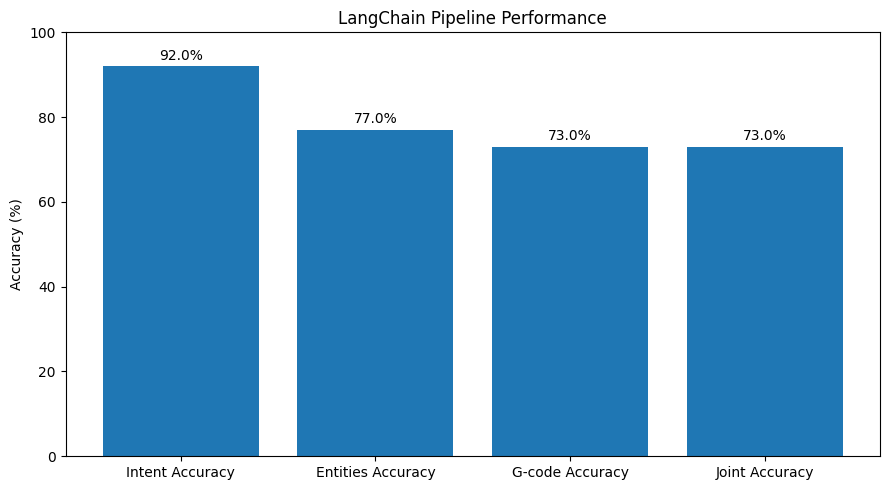

In [ ]:
def plot_metrics_bar(metrics: dict, title="LangChain Pipeline Performance"):
    labels = ["Intent Accuracy", "Entities Accuracy", "G-code Accuracy", "Joint Accuracy"]
    values = [
        metrics["intent_accuracy"] * 100,
        metrics["entity_accuracy"] * 100,
        metrics["gcode_accuracy"] * 100,
        metrics["joint_accuracy"] * 100,
    ]

    plt.figure(figsize=(9, 5))
    plt.bar(labels, values)
    plt.ylim(0, 100)
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    for i, v in enumerate(values):
        plt.text(i, v + 1.5, f"{v:.1f}%", ha="center")
    plt.tight_layout()
    plt.show()


plot_metrics_bar(metrics)

In [ ]:
def show_failures(df_eval, N=80, seed=42, k=10):
    sample = df_eval.sample(n=min(N, len(df_eval)), random_state=seed).reset_index(drop=True)
    shown = 0

    for sent, gold_i, gold_g in zip(sample["sentence"], sample["intent"], sample["gcode_true"]):
        pred = predict_one(sent)
        pg = normalize_gcode(pred["gcode"])
        gg = normalize_gcode(gold_g)

        ent_ok = entities_match(pg, gg, tol=0.0)
        ok = (pred["intent"] == str(gold_i)) and (pg == gg) and ent_ok

        if not ok:
            print("\nSENT:", sent)
            print("GOLD intent:", gold_i)
            print("PRED intent:", pred["intent"])
            print("GOLD gcode:", gg)
            print("PRED gcode:", pg)
            print("PRED fields:", pred["fields"])
            print("Entities match?", ent_ok)
            shown += 1
            if shown >= k:
                break

show_failures(df_eval, N=100, seed=42, k=10)



SENT: Move the grinding wheel to X6 Z-10 for a spark-out.
GOLD intent: grind_linear
PRED intent: grind_linear
GOLD gcode: G01 X6 Z-10 F_PRECISE
PRED gcode: G01 X6 Z-10 F_STANDARD
PRED fields: {'intent': 'grind_linear', 'x_value': 6, 'z_value': -10, 'descriptor': 'spark-out', 'F_number': None}
Entities match? False

SENT: Place the grinding wheel to X-20.
GOLD intent: pure_positioning
PRED intent: grind_linear
GOLD gcode: G00 X-20
PRED gcode: G01 X-20 Z0 F_STANDARD
PRED fields: {'intent': 'grind_linear', 'x_value': -20, 'z_value': None, 'descriptor': None, 'F_number': None}
Entities match? False

SENT: Move to X-10 Z0 for inspection.
GOLD intent: pure_positioning
PRED intent: pure_positioning
GOLD gcode: G00 X-10
PRED gcode: G00 X-10 Z0
PRED fields: {'intent': 'pure_positioning', 'x_value': -10, 'z_value': 0, 'descriptor': None, 'F_number': None}
Entities match? False

SENT: Position the grinding wheel at X21 Z0.
GOLD intent: pure_positioning
PRED intent: grind_linear
GOLD gcode: G00 X

In [ ]:
import json

with open("/content/Langchain_2.ipynb") as f:
    nb = json.load(f)

code_lines = 0
code_cells = 0

for cell in nb["cells"]:
    if cell["cell_type"] == "code":
        code_cells += 1
        code_lines += len(cell["source"])

print("Code cells:", code_cells)
print("Total code lines:", code_lines)

Code cells: 18
Total code lines: 330
